# Task 1: Laying the Foundation for Change Point Analysis

## Objective
Define the data analysis workflow and develop a thorough understanding of Brent oil prices and how geopolitical events impact the market.

---


## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Statistical tests
from statsmodels.tsa.stattools import adfuller
from scipy import stats

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## 2. Load and Inspect Data

In [2]:
from pathlib import Path
import pandas as pd

# Load data
data_path = Path("../data/raw/BrentOilPrices.csv")
df = pd.read_csv(data_path)

# Automatically parse mixed date formats
df["Date"] = pd.to_datetime(df["Date"], format="mixed")

# Sort by date
df = df.sort_values("Date").reset_index(drop=True)

print(f"Data shape: {df.shape}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")

print(df.head())

Data shape: (9011, 2)
Date range: 1987-05-20 00:00:00 to 2022-11-14 00:00:00
        Date  Price
0 1987-05-20  18.63
1 1987-05-21  18.45
2 1987-05-22  18.55
3 1987-05-25  18.60
4 1987-05-26  18.63


## 3. Data Quality Checks

In [3]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Basic statistics
print(f"\n{df['Price'].describe()}")

# Check for duplicates
print(f"\nDuplicate dates: {df['Date'].duplicated().sum()}")
print(f"Duplicate prices: {df['Price'].duplicated().sum()}")

# Data type validation
print(f"\nData types:\n{df.dtypes}")
print(df.isnull().sum())

Missing values:
Date     0
Price    0
dtype: int64

count    9011.000000
mean       48.420782
std        32.860110
min         9.100000
25%        19.050000
50%        38.570000
75%        70.090000
max       143.950000
Name: Price, dtype: float64

Duplicate dates: 0
Duplicate prices: 3996

Data types:
Date     datetime64[us]
Price           float64
dtype: object
Date     0
Price    0
dtype: int64


## 4. Time Series Visualization

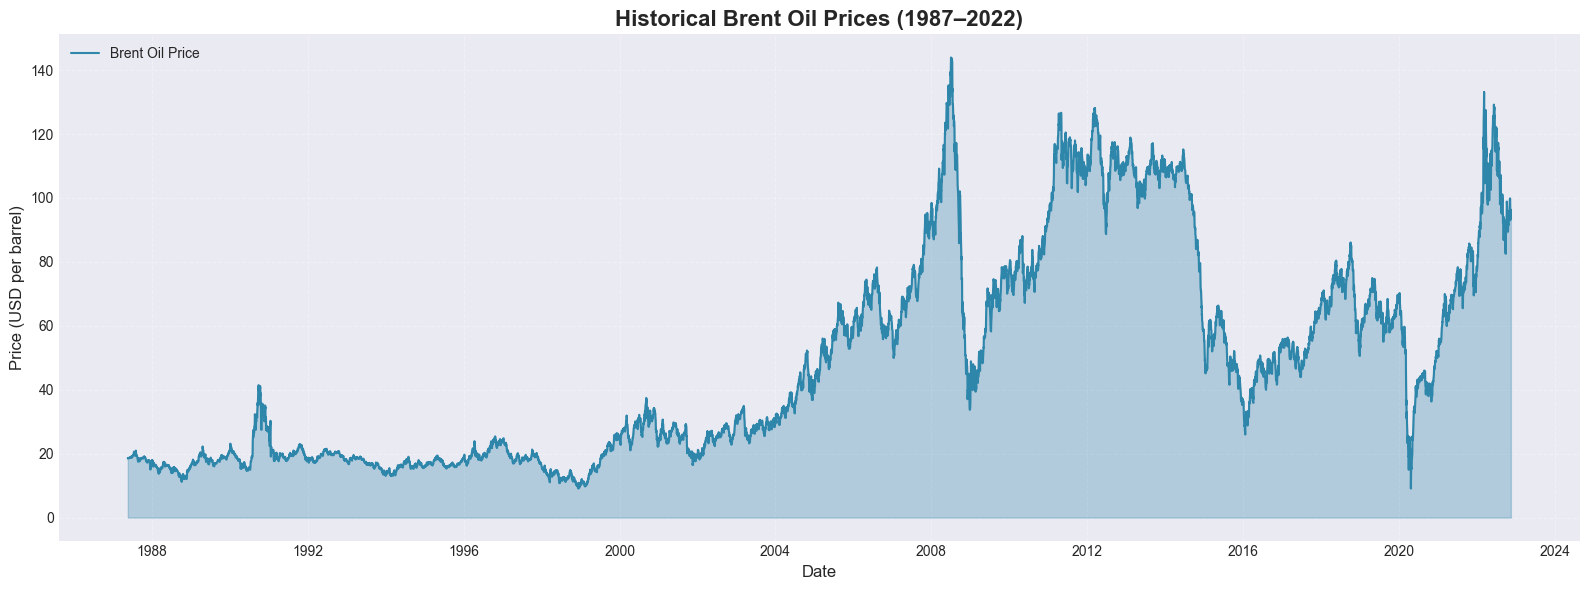

BRENT OIL PRICE SUMMARY
Number of observations : 9,011
Date range             : 1987-05-20 to 2022-11-14
Minimum price          : $9.10
Maximum price          : $143.95
Average price          : $48.42
Median price           : $38.57
Standard deviation     : $32.86


In [4]:
from pathlib import Path
import matplotlib.pyplot as plt

# Create output directory if it doesn't exist
output_dir = Path("../reports/figures")
output_dir.mkdir(parents=True, exist_ok=True)

# Plot Brent oil prices
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(
    df["Date"],
    df["Price"],
    linewidth=1.5,
    color="#2E86AB",
    label="Brent Oil Price"
)

ax.fill_between(
    df["Date"],
    df["Price"],
    alpha=0.3,
    color="#2E86AB"
)

ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Price (USD per barrel)", fontsize=12)

ax.set_title(
    "Historical Brent Oil Prices (1987–2022)",
    fontsize=16,
    fontweight="bold"
)

ax.legend(loc="upper left")
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()

# Save figure
plt.savefig(
    output_dir / "01_timeseries_overview.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Summary statistics
print("=" * 60)
print("BRENT OIL PRICE SUMMARY")
print("=" * 60)
print(f"Number of observations : {len(df):,}")
print(f"Date range             : {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Minimum price          : ${df['Price'].min():.2f}")
print(f"Maximum price          : ${df['Price'].max():.2f}")
print(f"Average price          : ${df['Price'].mean():.2f}")
print(f"Median price           : ${df['Price'].median():.2f}")
print(f"Standard deviation     : ${df['Price'].std():.2f}")

In [5]:
import sys

!{sys.executable} -m pip install pymc arviz

In [6]:
from pathlib import Path
import pandas as pd

# Load Brent oil prices
data_path = Path("../data/raw/BrentOilPrices.csv")
df = pd.read_csv(data_path)

# Convert dates
df["Date"] = pd.to_datetime(df["Date"], format="mixed")

# Sort by date
df = df.sort_values("Date").reset_index(drop=True)

print(df.head())
print(df.shape)

        Date  Price
0 1987-05-20  18.63
1 1987-05-21  18.45
2 1987-05-22  18.55
3 1987-05-25  18.60
4 1987-05-26  18.63
(9011, 2)


In [7]:
print(df.columns)

Index(['Date', 'Price'], dtype='str')


In [8]:
import numpy as np

prices = df["Price"].values
N = len(prices)

print(f"Number of observations: {N}")

Number of observations: 9011


In [9]:
import pymc as pm

with pm.Model() as model:
    tau = pm.DiscreteUniform("tau", lower=0, upper=N - 1)

    mu1 = pm.Normal("mu1", mu=prices.mean(), sigma=20)
    mu2 = pm.Normal("mu2", mu=prices.mean(), sigma=20)

    sigma = pm.HalfNormal("sigma", sigma=10)

    mu = pm.math.switch(np.arange(N) < tau, mu1, mu2)

    obs = pm.Normal(
        "obs",
        mu=mu,
        sigma=sigma,
        observed=prices
    )

    trace = pm.sample(
        draws=2000,
        tune=1000,
        target_accept=0.95,
        random_seed=42,
        return_inferencedata=True
    )

g++ not available, if using conda: `conda install gxx`


Multiprocess sampling (4 chains in 4 jobs)


CompoundStep


>Metropolis: [tau]


>NUTS: [mu1, mu2, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 17 seconds.


In [10]:
tau_estimate = int(trace.posterior["tau"].mean().values)

change_date = df.iloc[tau_estimate]["Date"]

print(f"Estimated change point index: {tau_estimate}")
print(f"Estimated change point date : {change_date}")

Estimated change point index: 4520
Estimated change point date : 2005-02-23 00:00:00


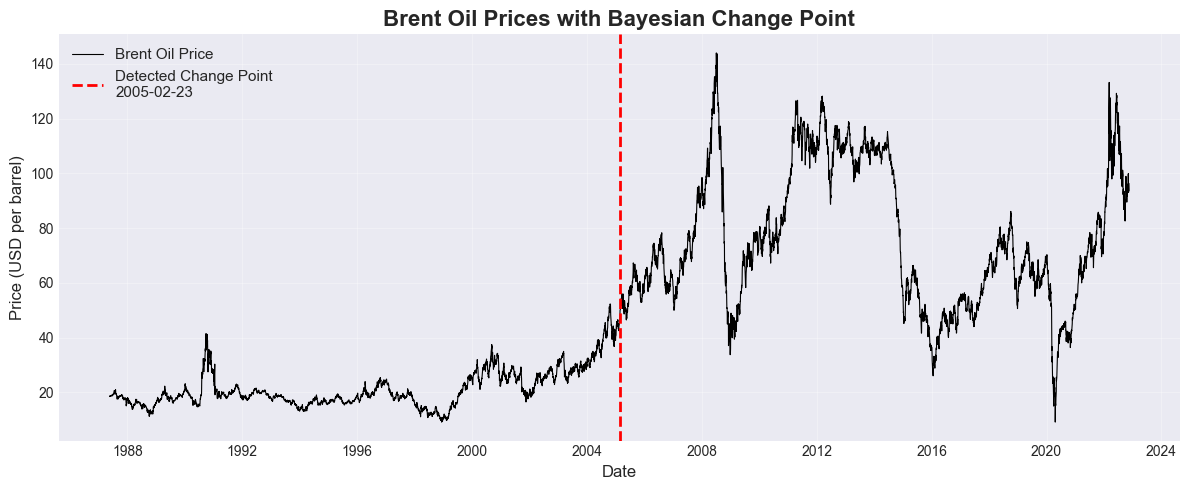

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    df["Date"],
    df["Price"],
    color="black",
    linewidth=0.8,
    label="Brent Oil Price"
)

ax.axvline(
    change_date,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Detected Change Point\n{change_date.date()}"
)

ax.set_title(
    "Brent Oil Prices with Bayesian Change Point",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Price (USD per barrel)", fontsize=12)

ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

## 5. Trend Analysis

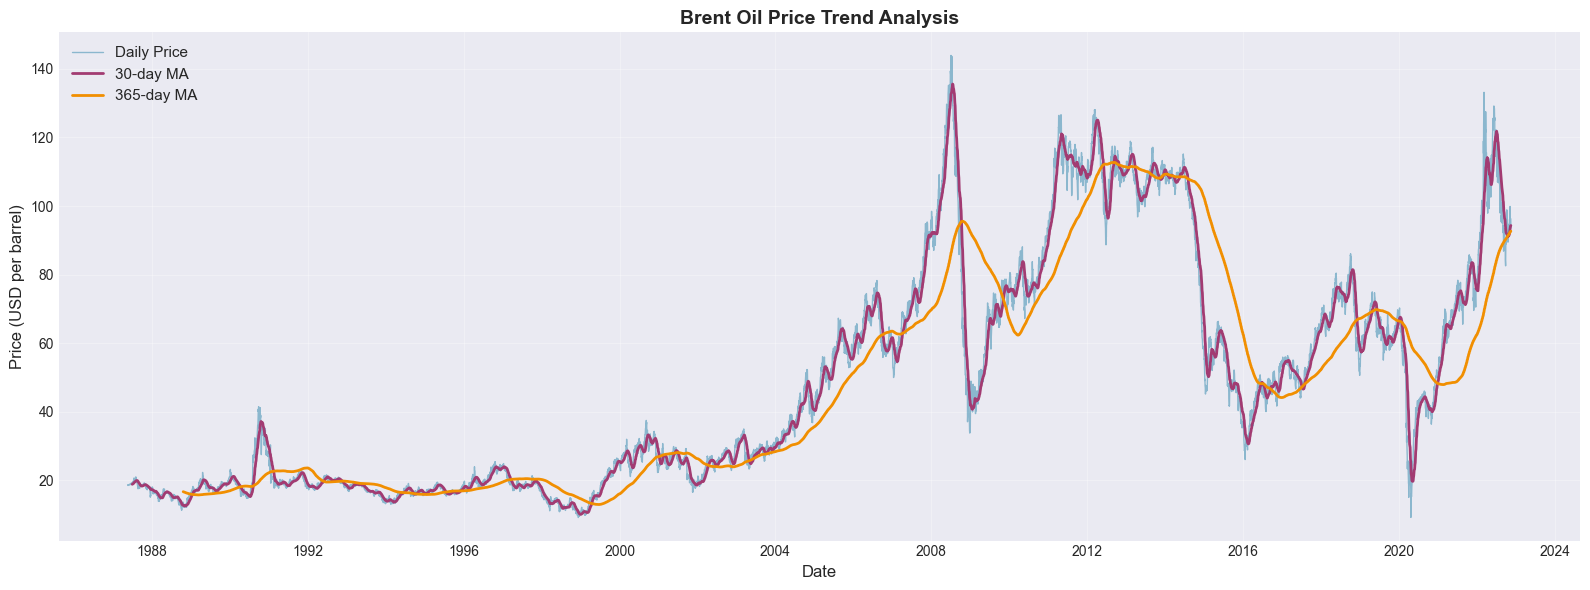

Trend identified: Long-term moving average (365-day) shows decadal patterns


In [12]:
# Calculate rolling averages for trend
df['MA_30'] = df['Price'].rolling(window=30).mean()
df['MA_365'] = df['Price'].rolling(window=365).mean()

# Plot with moving averages
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df['Date'], df['Price'], label='Daily Price', linewidth=1, alpha=0.5, color='#2E86AB')
ax.plot(df['Date'], df['MA_30'], label='30-day MA', linewidth=2, color='#A23B72')
ax.plot(df['Date'], df['MA_365'], label='365-day MA', linewidth=2, color='#F18F01')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price (USD per barrel)', fontsize=12)
ax.set_title('Brent Oil Price Trend Analysis', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/02_trend_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Trend identified: Long-term moving average (365-day) shows decadal patterns")

## 6. Log Returns Calculation

In [13]:
# Calculate log returns
df['Log_Returns'] = np.log(df['Price'] / df['Price'].shift(1))

# Remove first NaN value
returns_clean = df['Log_Returns'].dropna()

print(f"Log Returns Statistics:")
print(returns_clean.describe())
print(f"\nSkewness: {returns_clean.skew():.4f}")
print(f"Kurtosis: {returns_clean.kurtosis():.4f}")

Log Returns Statistics:
count    9010.000000
mean        0.000179
std         0.025532
min        -0.643699
25%        -0.011154
50%         0.000402
75%         0.012127
max         0.412023
Name: Log_Returns, dtype: float64

Skewness: -1.7444
Kurtosis: 65.9047


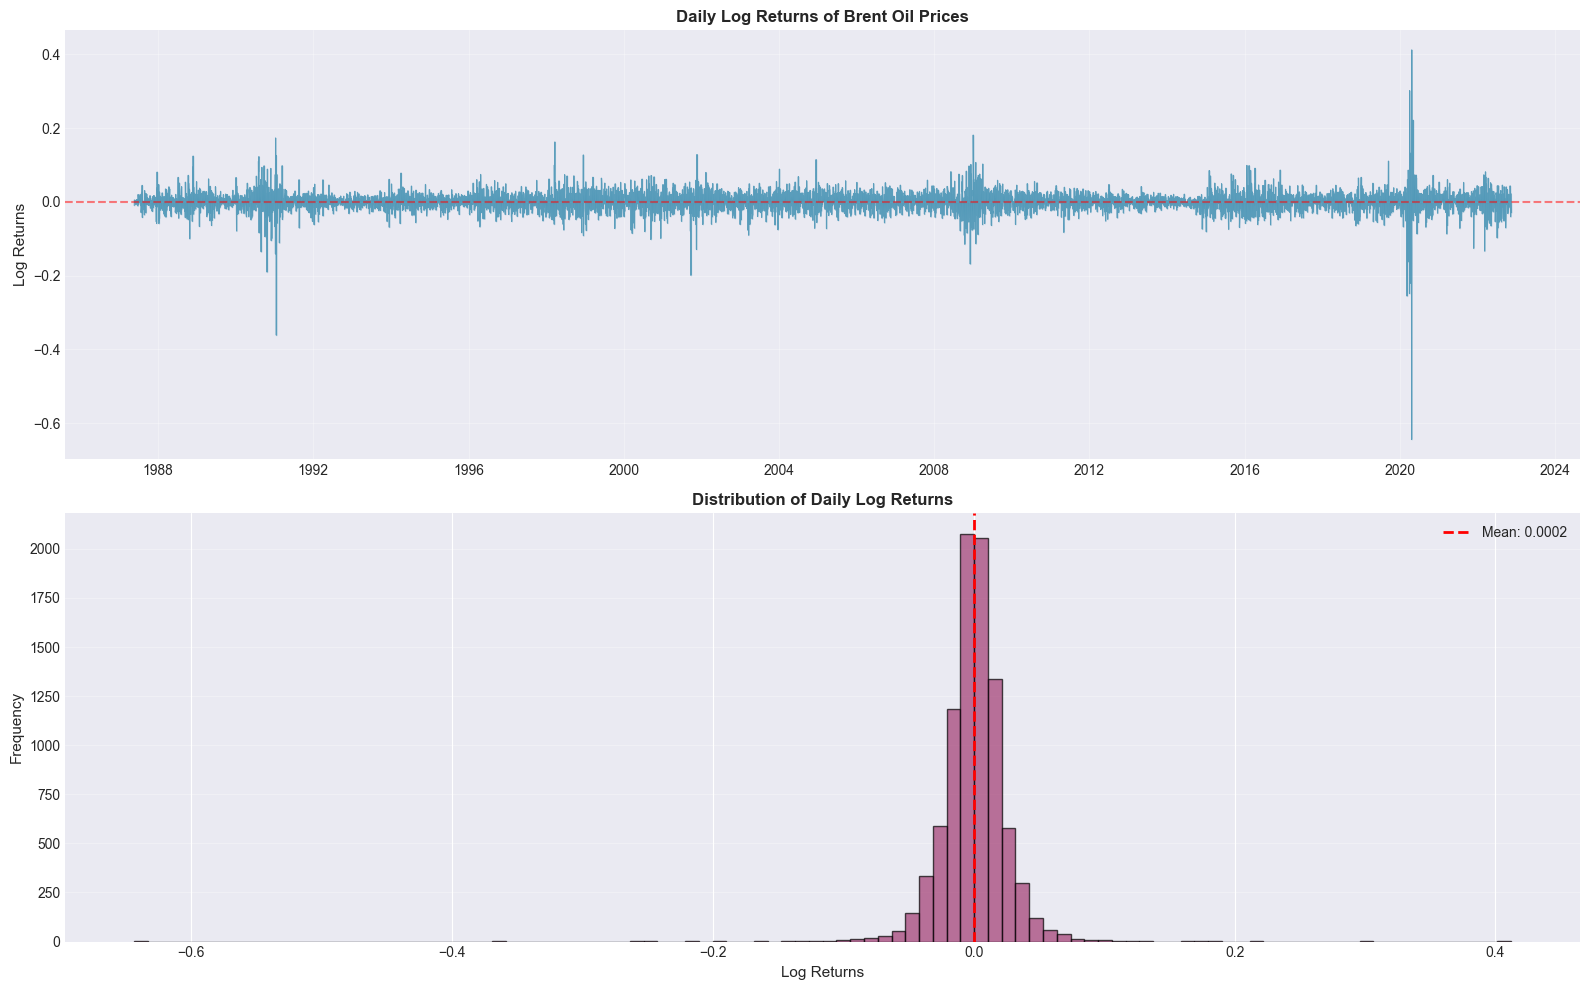

In [14]:
# Plot log returns
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Time series of returns
axes[0].plot(df['Date'][1:], df['Log_Returns'][1:], linewidth=0.8, alpha=0.7, color='#2E86AB')
axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[0].fill_between(df['Date'][1:], df['Log_Returns'][1:], alpha=0.2, color='#2E86AB')
axes[0].set_ylabel('Log Returns', fontsize=11)
axes[0].set_title('Daily Log Returns of Brent Oil Prices', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Histogram of returns
axes[1].hist(returns_clean, bins=100, alpha=0.7, color='#A23B72', edgecolor='black')
axes[1].axvline(returns_clean.mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {returns_clean.mean():.4f}")
axes[1].set_xlabel('Log Returns', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Distribution of Daily Log Returns', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../reports/figures/03_log_returns.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Stationarity Testing (ADF Test)

In [15]:
# ADF test on raw prices
print("="*70)
print("ADF TEST: RAW PRICES")
print("="*70)

adf_price = adfuller(df['Price'].dropna())
print(f"Test Statistic: {adf_price[0]:.6f}")
print(f"P-value: {adf_price[1]:.6f}")
print(f"Lags Used: {adf_price[2]}")
print(f"\nCritical Values:")
for key, value in adf_price[4].items():
    print(f"  {key}: {value:.3f}")

if adf_price[1] < 0.05:
    print("\n✓ Result: STATIONARY (reject null hypothesis, p < 0.05)")
else:
    print("\n✗ Result: NON-STATIONARY (fail to reject null, p >= 0.05)")

print("\nInterpretation: Raw prices are NON-STATIONARY")
print("This is expected - prices tend to have unit roots and trends.")

ADF TEST: RAW PRICES


Test Statistic: -1.993856
P-value: 0.289274
Lags Used: 29

Critical Values:
  1%: -3.431
  5%: -2.862
  10%: -2.567

✗ Result: NON-STATIONARY (fail to reject null, p >= 0.05)

Interpretation: Raw prices are NON-STATIONARY
This is expected - prices tend to have unit roots and trends.


In [16]:
# ADF test on log returns
print("\n" + "="*70)
print("ADF TEST: LOG RETURNS")
print("="*70)

adf_returns = adfuller(returns_clean)
print(f"Test Statistic: {adf_returns[0]:.6f}")
print(f"P-value: {adf_returns[1]:.6f}")
print(f"Lags Used: {adf_returns[2]}")
print(f"\nCritical Values:")
for key, value in adf_returns[4].items():
    print(f"  {key}: {value:.3f}")

if adf_returns[1] < 0.05:
    print("\n✓ Result: STATIONARY (reject null hypothesis, p < 0.05)")
else:
    print("\n✗ Result: NON-STATIONARY (fail to reject null, p >= 0.05)")

print("\nInterpretation: Log returns are STATIONARY")
print("This is expected - returns should be mean-reverting.")


ADF TEST: LOG RETURNS


Test Statistic: -16.427113
P-value: 0.000000
Lags Used: 28

Critical Values:
  1%: -3.431
  5%: -2.862
  10%: -2.567

✓ Result: STATIONARY (reject null hypothesis, p < 0.05)

Interpretation: Log returns are STATIONARY
This is expected - returns should be mean-reverting.


## 8. Volatility Analysis

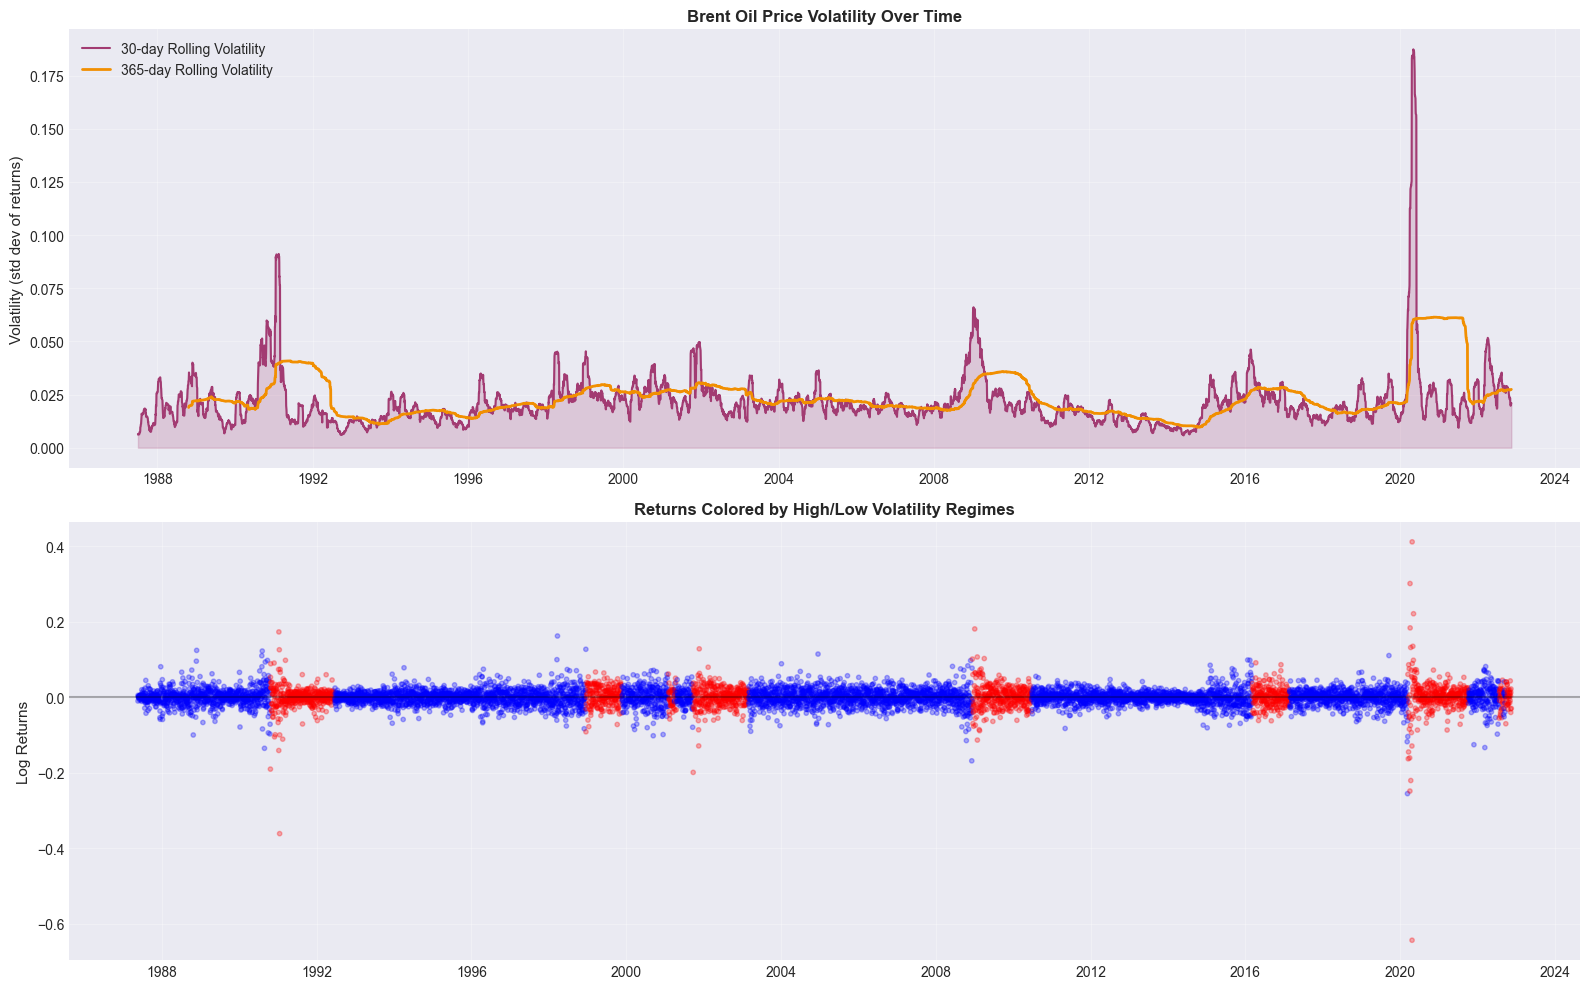

Volatility Statistics:
Mean 30-day volatility: 0.021564
Mean 365-day volatility: 0.023554
High volatility threshold (75th percentile): 0.026887


In [17]:
# Calculate rolling volatility (30-day and 365-day)
df['Volatility_30'] = df['Log_Returns'].rolling(window=30).std()
df['Volatility_365'] = df['Log_Returns'].rolling(window=365).std()

# Plot volatility
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Volatility over time
axes[0].plot(df['Date'], df['Volatility_30'], label='30-day Rolling Volatility', linewidth=1.5, color='#A23B72')
axes[0].plot(df['Date'], df['Volatility_365'], label='365-day Rolling Volatility', linewidth=2, color='#F18F01')
axes[0].fill_between(df['Date'], df['Volatility_30'], alpha=0.2, color='#A23B72')
axes[0].set_ylabel('Volatility (std dev of returns)', fontsize=11)
axes[0].set_title('Brent Oil Price Volatility Over Time', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Returns colored by volatility regime
high_vol_threshold = df['Volatility_365'].quantile(0.75)
colors = ['red' if vol > high_vol_threshold else 'blue' for vol in df['Volatility_365']]
axes[1].scatter(df['Date'], df['Log_Returns'], alpha=0.3, s=10, c=colors)
axes[1].axhline(y=0, color='black', linestyle='-', alpha=0.3)
axes[1].set_ylabel('Log Returns', fontsize=11)
axes[1].set_title('Returns Colored by High/Low Volatility Regimes', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/04_volatility_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Volatility Statistics:")
print(f"Mean 30-day volatility: {df['Volatility_30'].mean():.6f}")
print(f"Mean 365-day volatility: {df['Volatility_365'].mean():.6f}")
print(f"High volatility threshold (75th percentile): {high_vol_threshold:.6f}")

## 9. Load and Explore Event Data

In [18]:
# Load geopolitical events
from prometheus_client import Summary


events_path = Path('../data/events.csv')
events_df = pd.read_csv(events_path)
events_df['Date'] = pd.to_datetime(events_df['Date'])

print(f"Loaded {len(events_df)} geopolitical events")
print(f"\nEvents summary:")
print(events_df[['Date', 'Event', 'Category', 'Severity']].to_string())

Loaded 19 geopolitical events

Events summary:
         Date                              Event                       Category Severity
0  1973-10-19                   OPEC Oil Embargo     OPEC Policy / Geopolitical     High
1  1979-01-01                 Iranian Revolution    Geopolitical / Supply Shock     High
2  1980-09-22                      Iran-Iraq War    Geopolitical / Supply Shock     High
3  1990-08-02            Iraq Invasion of Kuwait                   Geopolitical     High
4  1991-01-17  Operation Desert Storm (Gulf War)    Geopolitical / Supply Shock     High
5  1997-11-27        OPEC Jakarta Quota Increase                    OPEC Policy   Medium
6  1997-12-01      Asian Financial Crisis Impact                 Economic Shock     High
7  2001-09-11             9/11 Terrorist Attacks  Geopolitical / Economic Shock     High
8  2003-03-20                US Invasion of Iraq                   Geopolitical     High
9  2008-07-01       Global Financial Crisis Peak               

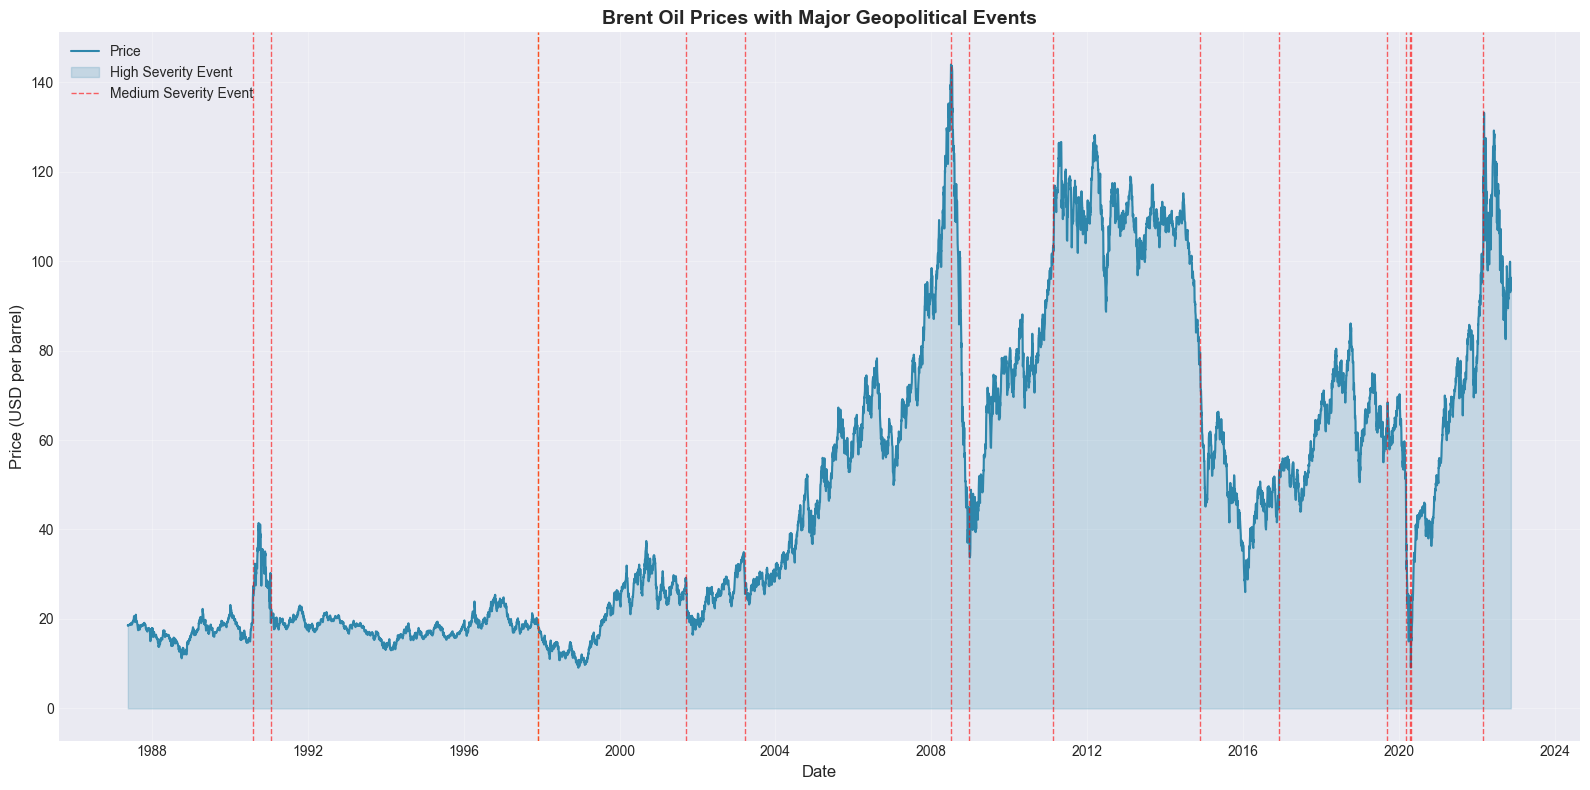

In [19]:
# Plot time series with events highlighted
fig, ax = plt.subplots(figsize=(16, 8))

# Plot price
ax.plot(df['Date'], df['Price'], linewidth=1.5, color='#2E86AB', label='Price')
ax.fill_between(df['Date'], df['Price'], alpha=0.2, color='#2E86AB')

# Add event lines
for idx, event in events_df.iterrows():
    event_date = event['Date']
    # Filter for events within data range
    if df['Date'].min() <= event_date <= df['Date'].max():
        # Color by severity
        color = 'red' if event['Severity'] == 'High' else 'orange' if event['Severity'] == 'Medium' else 'yellow'
        ax.axvline(event_date, color=color, linestyle='--', alpha=0.6, linewidth=1)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price (USD per barrel)', fontsize=12)
ax.set_title('Brent Oil Prices with Major Geopolitical Events', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(['Price', 'High Severity Event', 'Medium Severity Event'], fontsize=10)

plt.tight_layout()
plt.savefig('../reports/figures/05_events_overlay.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. Task 1 Summary and Key Findings

In [20]:
print("\n" + "="*70)
print("TASK 1: DATA ANALYSIS FOUNDATION - SUMMARY")
print("="*70)

print(f"""
DATA OVERVIEW:
  • Time period: {df['Date'].min().strftime('%Y-%m-%d')} to {df['Date'].max().strftime('%Y-%m-%d')}
  • Number of observations: {len(df):,} days
  • Price range: ${df['Price'].min():.2f} - ${df['Price'].max():.2f}
  • Mean price: ${df['Price'].mean():.2f}
  • Standard deviation: ${df['Price'].std():.2f}

STATISTICAL PROPERTIES:
  ✗ Raw prices: NON-STATIONARY (ADF p-value = {adf_price[1]:.6f})
  ✓ Log returns: STATIONARY (ADF p-value = {adf_returns[1]:.6f})
  • Mean daily return: {returns_clean.mean()*100:.4f}%
  • Daily volatility: {returns_clean.std()*100:.4f}%
  • Return skewness: {returns_clean.skew():.4f} (negative skew - large drops more likely)
  • Return kurtosis: {returns_clean.kurtosis():.4f} (fat tails - extreme events more likely)

VOLATILITY REGIMES:
  • Mean 30-day volatility: {df['Volatility_30'].mean()*100:.4f}%
  • Mean 365-day volatility: {df['Volatility_365'].mean()*100:.4f}%
  • High volatility periods clearly visible around major events

GEOPOLITICAL EVENTS:
  • Total events compiled: {len(events_df)}
  • Events in data period: {len(events_df[events_df['Date'] >= df['Date'].min()])}
  • Events by category:
""")

print(events_df['Category'].value_counts().to_string())

print(f"""
KEY INSIGHTS FOR CHANGE POINT MODELING:
  1. Prices show clear structural breaks around major events
  2. Volatility clustering visible - high volatility tends to persist
  3. Mean prices shift between regimes (calm vs. crisis periods)
  4. Log returns are stationary - suitable for Bayesian modeling
  5. Fat-tailed distribution - useful for identifying outliers/shocks

MODELING IMPLICATIONS:
  • Use PRICES (level) for change point detection of regime shifts
  • Consider log returns for volatility-based models
  • Multiple change points likely (not just one)
  • Heteroskedasticity important (different volatility across regimes)
  • Event timing provides external validation for change points

NEXT STEPS (TASK 2):
  1. Build PyMC Bayesian change point model
  2. Implement switch function for regime dynamics
  3. Run MCMC sampling (4 chains, 4000 iterations)
  4. Check convergence diagnostics
  5. Identify posterior change point date(s)
  6. Quantify before/after price shifts
  7. Associate with geopolitical events
""")

print("="*70)


TASK 1: DATA ANALYSIS FOUNDATION - SUMMARY

DATA OVERVIEW:
  • Time period: 1987-05-20 to 2022-11-14
  • Number of observations: 9,011 days
  • Price range: $9.10 - $143.95
  • Mean price: $48.42
  • Standard deviation: $32.86

STATISTICAL PROPERTIES:
  ✗ Raw prices: NON-STATIONARY (ADF p-value = 0.289274)
  ✓ Log returns: STATIONARY (ADF p-value = 0.000000)
  • Mean daily return: 0.0179%
  • Daily volatility: 2.5532%
  • Return skewness: -1.7444 (negative skew - large drops more likely)
  • Return kurtosis: 65.9047 (fat tails - extreme events more likely)

VOLATILITY REGIMES:
  • Mean 30-day volatility: 2.1564%
  • Mean 365-day volatility: 2.3554%
  • High volatility periods clearly visible around major events

GEOPOLITICAL EVENTS:
  • Total events compiled: 19
  • Events in data period: 16
  • Events by category:

Category
OPEC Policy                      5
Geopolitical / Supply Shock      4
Geopolitical                     3
Economic Shock                   3
OPEC Policy / Geopolit

✅ events.csv saved successfully!
Location: F:\Kifiya\Kifiya 10\change-point-analysis\data\events.csv
        Date                        Event                     Category  \
0 1973-10-19             OPEC Oil Embargo   OPEC Policy / Geopolitical   
1 1979-01-01           Iranian Revolution  Geopolitical / Supply Shock   
2 1980-09-22                Iran-Iraq War  Geopolitical / Supply Shock   
3 1990-08-02      Iraq Invasion of Kuwait                 Geopolitical   
4 1997-11-27  OPEC Jakarta Quota Increase                  OPEC Policy   

  Severity                                     Impact Summary  
0     High  Arab OPEC members declare embargo against nati...  
1     High  Political upheaval in Iran severely reduces gl...  
2     High  Hostilities disrupt oil exports from both nati...  
3     High  Iraqi invasion causes immediate spike in globa...  
4   Medium  OPEC decides to raise production quotas amid o...  
